# 1. Setup

## Environment

In [1]:
!nvidia-smi

Wed Feb 25 21:28:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      4
  On-line CPU(s) list:       0-3
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      2
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.30
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [3]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            31Gi       762Mi        28Gi       2.0Mi       2.5Gi        30Gi
Swap:             0B          0B          0B


In [4]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.4 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [5]:
!df -h

Filesystem                                                               Size  Used Avail Use% Mounted on
overlay                                                                  7.9T  6.6T  1.4T  83% /
tmpfs                                                                     64M     0   64M   0% /dev
shm                                                                       14G     0   14G   0% /dev/shm
/dev/loop1                                                                20G  232K   20G   1% /kaggle/lib
192.168.13.2:/data/kagglesdsdata/datasets/7699161/14447508/dgmtcdegzgqp   75T   55T   21T  73% /kaggle/input/datasets/angelolmg/tilda-400
/dev/sda1                                                                122G  3.5G  119G   3% /opt/bin
/dev/mapper/snap                                                         7.9T  6.6T  1.4T  83% /etc/hosts
tmpfs                                                                     16G     0   16G   0% /proc/acpi
tmpfs                           

## Libraries

In [6]:
# ==========================================
# 1. INSTALLS & SETUP
# ==========================================
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 2. STANDARD LIBRARIES
# ==========================================
import os
import gc
import time
import copy
import json
import shutil
import random
from tqdm import tqdm
from glob import glob
from datetime import datetime
from collections import defaultdict

# ==========================================
# 3. DATA & VISUALIZATION
# ==========================================
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# ==========================================
# 4. MACHINE LEARNING & METRICS (Scikit-Learn)
# ==========================================
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, roc_auc_score, confusion_matrix
)

# ==========================================
# 5. DEEP LEARNING (PyTorch & timm)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler
import timm

In [7]:
!pip freeze > requirements.txt

## Constants

In [8]:
# ==========================================
# 7. MASTER CONFIGURATION
# ==========================================
class CFG:
    DATASET = "TILDA" # ['TILDA', 'HKU']
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 0.05
    
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 4
    
    OUTPUT_DIR = "./patches"
    BASE_INPUT_PATH = "./patches/64"
    SPLITS_CSV_PATH = "/kaggle/working/master_splits_64.csv"
    PATCH_SIZE = 64
    N_IMAGES = 4

    DATASETS_INFO = {
        "TILDA": {
            "root": "/kaggle/input/datasets/angelolmg/tilda-400",
            "patch_sizes": [64],
            "tolerance": 0.05,
            "clamp": 0.1,
            "classes": {
                0: "hole", 1: "foreign_objects", 2: "oil_spot", 3: "thread_error"
            },
            "colors": {
                "good": (0, 155, 0), "hole": (255, 0, 0), 
                "foreign_objects": (0, 0, 255), "oil_spot": (255, 165, 0), 
                "thread_error": (128, 0, 128)
            }
        },
        "HKU": {
            "root": "/kaggle/input/datasets/angelolmg/hku-dataset",
            "patch_sizes": [64],
            "tolerance": 0.05,
            "clamp": 0.1,
            "classes": {
                0: "BrokenEnd", 1: "Hole", 2: "NettingMultiple", 
                3: "ThickBar", 4: "ThinBar", 5: "Knots"
            },
            "colors": {
                "good": (0, 155, 0), "BrokenEnd": (255, 0, 0), 
                "Hole": (0, 0, 255), "NettingMultiple": (255, 165, 0), 
                "ThickBar": (128, 0, 128), "ThinBar": (0, 255, 255), "Knots": (255, 255, 0)
            }
        }
    }

    @classmethod
    def get_active_info(cls):
        return cls.DATASETS_INFO[cls.DATASET]

active_data = CFG.get_active_info()

print(f"[INFO] DATASET: {CFG.DATASET}")
print(f"[INFO] ROOT: {active_data['root']}")
print(f"[INFO] CLASSES: {list(active_data['classes'].values())}")
print(f"[INFO] DEVICE: {CFG.DEVICE.upper()}")

[INFO] DATASET: TILDA
[INFO] ROOT: /kaggle/input/datasets/angelolmg/tilda-400
[INFO] CLASSES: ['hole', 'foreign_objects', 'oil_spot', 'thread_error']
[INFO] DEVICE: CUDA


## Seed

In [9]:
def set_seed(seed: int = 42) -> None:
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # Set seed for CUDA (if using GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    #tf.random.set_seed(seed) # set random seed for TensorFlow
    print(f"[INFO] Random seed set as {seed}")

set_seed(CFG.SEED)

[INFO] Random seed set as 42


# 2. Dataset

## Patch extraction

In [10]:
# ==========================================
# 8. DATA EXTRACTION (PATCHING ROUTER)
# ==========================================

def _extract_patches_tilda():
    img_dir = os.path.join(active_data['root'], "images")
    lbl_dir = os.path.join(active_data['root'], "labels")
    msk_dir = os.path.join(active_data['root'], "masks")

    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
    image_paths = sorted(glob(os.path.join(img_dir, "*.tif")))

    patch_counts = {
        res: {cname: 0 for cname in list(active_data['classes'].values()) + ["good"]}
        for res in active_data['patch_sizes']
    }

    for img_path in image_paths:
        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")
        msk_path = os.path.join(msk_dir, base + ".png")

        if not os.path.exists(lbl_path) or not os.path.exists(msk_path):
            continue

        image = np.array(Image.open(img_path))
        mask = np.array(Image.open(msk_path))
        if mask.ndim == 3: mask = mask[:, :, 0]

        total_defect_pixels = np.count_nonzero(mask)

        # Ler classe do TXT do YOLO
        with open(lbl_path, "r") as f:
            lines = f.readlines()
            
        if len(lines) == 0:
            class_name = "good"
        else:
            first_class_idx = int(lines[0].split()[0])
            class_name = active_data['classes'].get(first_class_idx, "good")

        required_dynamic = int(total_defect_pixels * active_data['tolerance'])
        if required_dynamic == 0 and total_defect_pixels > 0: required_dynamic = 1

        for res in active_data['patch_sizes']:
            res_dir = os.path.join(CFG.OUTPUT_DIR, str(res))
            for cname in list(active_data['classes'].values()) + ["good"]:
                os.makedirs(os.path.join(res_dir, cname), exist_ok=True)

            patch_area = res * res
            max_pixels_clamp = int(patch_area * active_data['clamp'])
            final_threshold = min(required_dynamic, max_pixels_clamp)
            if total_defect_pixels > 0 and final_threshold < 1: final_threshold = 1

            h, w = mask.shape
            for i in range(h // res):
                for j in range(w // res):
                    y, x = i * res, j * res
                    p_img = image[y:y+res, x:x+res]
                    p_mask = mask[y:y+res, x:x+res]
                    
                    if np.count_nonzero(p_mask) >= final_threshold and total_defect_pixels > 0:
                        save_class = class_name
                    else:
                        save_class = "good"

                    save_path = os.path.join(res_dir, save_class, f"{base}_patch{i}_{j}.tif")
                    Image.fromarray(p_img).save(save_path)
                    patch_counts[res][save_class] += 1

    return patch_counts

def _extract_patches_hku():
    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
    
    patch_counts = {
        res: {cname: 0 for cname in list(active_data['classes'].values()) + ["good"]}
        for res in active_data['patch_sizes']
    }
    
    pattern_folders = [
        "box-patterned-fabric_with_groundtruth",
        "dot-patterned_fabric_with_groundtruth",
        "star-patterned fabric_with_groundtruth" 
    ]

    for pattern in pattern_folders:
        pattern_path = os.path.join(active_data['root'], pattern)
        if not os.path.exists(pattern_path): continue
            
        prefix = pattern.split('-')[0]

        for class_folder in os.listdir(pattern_path):
            class_path = os.path.join(pattern_path, class_folder)
            if not os.path.isdir(class_path): continue

            class_name = "good" if class_folder == "Reference" else class_folder
            all_bmps = glob(os.path.join(class_path, "*.bmp"))
            image_paths = [p for p in all_bmps if not os.path.basename(p).startswith("groundT_")]

            for img_path in image_paths:
                base_name = os.path.basename(img_path)
                msk_name = f"groundT_{base_name}"
                msk_path = os.path.join(class_path, msk_name)

                image = np.array(Image.open(img_path))
                
                if class_name != "good" and os.path.exists(msk_path):
                    mask = np.array(Image.open(msk_path))
                else:
                    mask = np.zeros(image.shape[:2], dtype=np.uint8)

                if mask.ndim == 3: mask = mask[:, :, 0]
                total_defect_pixels = np.count_nonzero(mask)

                required_dynamic = int(total_defect_pixels * active_data['tolerance'])
                if required_dynamic == 0 and total_defect_pixels > 0: required_dynamic = 1

                for res in active_data['patch_sizes']:
                    res_dir = os.path.join(CFG.OUTPUT_DIR, str(res))
                    for cname in list(active_data['classes'].values()) + ["good"]:
                        os.makedirs(os.path.join(res_dir, cname), exist_ok=True)

                    patch_area = res * res
                    max_pixels_clamp = int(patch_area * active_data['clamp'])
                    final_threshold = min(required_dynamic, max_pixels_clamp)
                    if total_defect_pixels > 0 and final_threshold < 1: final_threshold = 1

                    h, w = mask.shape
                    for i in range(h // res):
                        for j in range(w // res):
                            y, x = i * res, j * res
                            p_img = image[y:y+res, x:x+res]
                            p_mask = mask[y:y+res, x:x+res]

                            if np.count_nonzero(p_mask) >= final_threshold and total_defect_pixels > 0:
                                save_class = class_name
                            else:
                                save_class = "good"

                            base_no_ext = os.path.splitext(base_name)[0]
                            save_path = os.path.join(res_dir, save_class, f"{prefix}_{base_no_ext}_patch{i}_{j}.tif")
                            Image.fromarray(p_img).save(save_path)
                            patch_counts[res][save_class] += 1

    return patch_counts

# --- ROUTER ---
def extract_patches():
    print(f"Extracting patches for dataset {CFG.DATASET}...")
    if CFG.DATASET == "TILDA":
        return _extract_patches_tilda()
    elif CFG.DATASET == "HKU":
        return _extract_patches_hku()
    else:
        raise ValueError("Dataset not supported.")

# ==========================
# ===== METADATA & ZIP =====
# ==========================

def save_metadata(patch_counts):
    meta_path = os.path.join(CFG.OUTPUT_DIR, "metadata.txt")

    with open(meta_path, "w") as f:
        f.write(f"Patch Extraction Metadata - {CFG.DATASET}\n")
        f.write("==========================\n")
        f.write(f"Date: {datetime.now()}\n")
        f.write(f"Dataset root: {active_data['root']}\n")
        f.write(f"Patch sizes: {active_data['patch_sizes']}\n")
        f.write(f"Tolerance: {active_data['tolerance']} ({active_data['tolerance']*100}%)\n")
        f.write(f"Clamp: {active_data['clamp']} ({active_data['clamp']*100}%)\n\n")

        f.write("Class mapping:\n")
        for k, v in active_data['classes'].items():
            f.write(f"  {k}: {v}\n")

        f.write("\nPatch Counts:\n")
        for res in active_data['patch_sizes']:
            f.write(f"\nResolution {res}x{res}:\n")
            for cname, count in patch_counts[res].items():
                f.write(f"  {cname}: {count}\n")

    print(f"Metadata saved in {meta_path}.")

def zip_output_folder(folder_path):
    zip_name = f"{CFG.DATASET}_{os.path.basename(os.path.abspath(folder_path))}.zip"
    zip_path = os.path.join(os.getcwd(), zip_name)

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                abs_path = os.path.join(root, file)
                rel_path = os.path.relpath(abs_path, folder_path)
                zf.write(abs_path, arcname=rel_path)

    print(f"ZIP created at: {zip_path}")
    return zip_path

In [11]:
set_seed(CFG.SEED)

patch_counts = extract_patches()
save_metadata(patch_counts)
# zip_output_folder(OUTPUT_DIR)

print("Patch extraction complete.")

[INFO] Random seed set as 42
Extracting patches for dataset TILDA...
Metadata saved in ./patches/metadata.txt.
Patch extraction complete.


In [12]:
# ==========================
# ===== CLENUP FILES ======
# ==========================

# PATCH_FOLDER = OUTPUT_DIR
# ZIP_FILE = os.path.basename(os.path.abspath(OUTPUT_DIR)) + ".zip"
# ZIP_PATH = os.path.join(os.getcwd(), ZIP_FILE)

# # Delete patches folder
# if os.path.exists(PATCH_FOLDER):
#     shutil.rmtree(PATCH_FOLDER)
#     print(f"Deleted folder: {PATCH_FOLDER}")
# else:
#     print("Patch folder not found.")

# # Delete zip file
# if os.path.exists(ZIP_PATH):
#     os.remove(ZIP_PATH)
#     print(f"Deleted zip file: {ZIP_PATH}")
# else:
#     print("Zip file not found.")

# print("Cleanup complete.")

## Visualization

Reading patches from: ./patches/64...
Total patches found: 38400


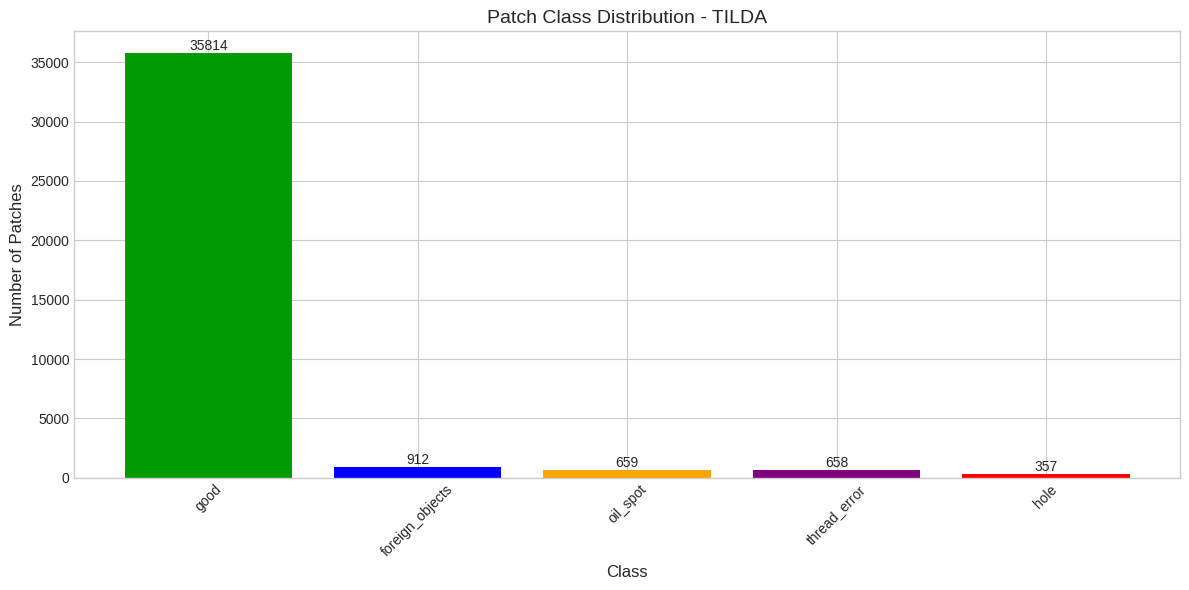

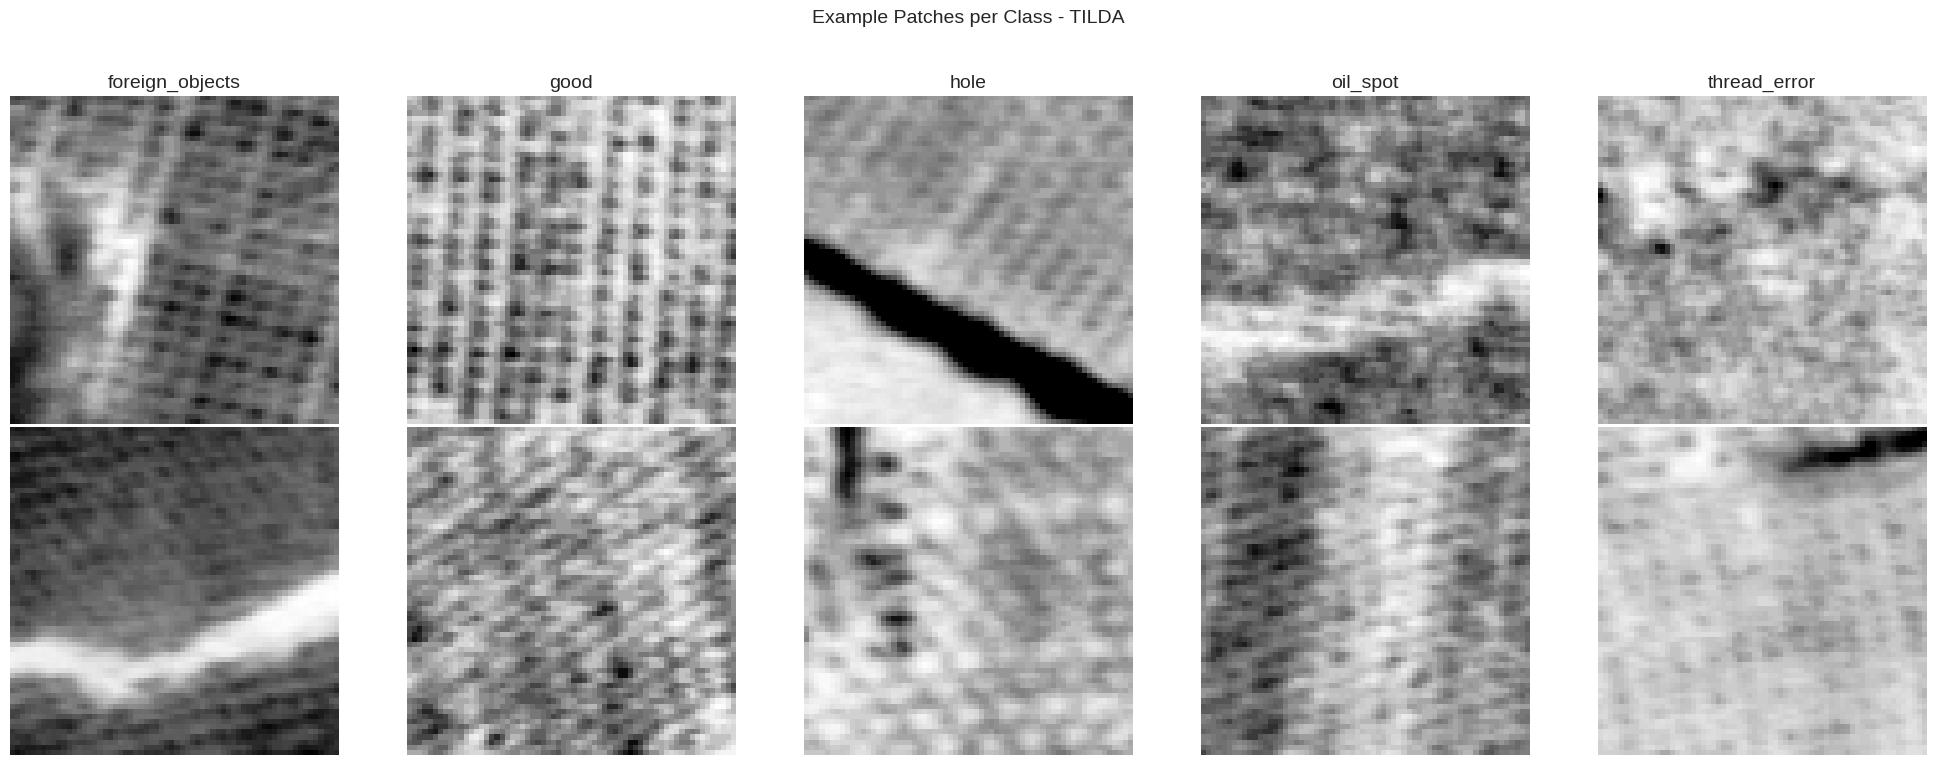

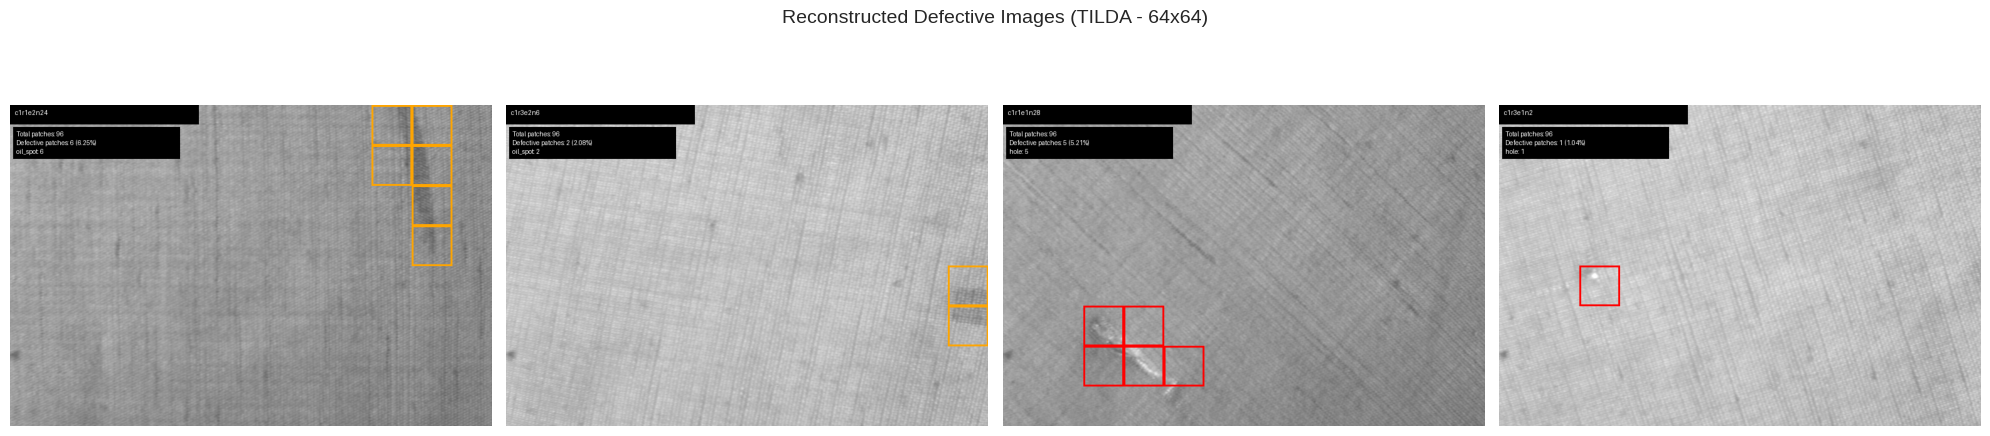

In [13]:
# ==========================================
# 9. DATA VISUALIZATION & EDA
# ==========================================

# Pegar as classes geradas na pasta atual
CLASS_NAMES = sorted([
    d for d in os.listdir(CFG.BASE_INPUT_PATH)
    if os.path.isdir(os.path.join(CFG.BASE_INPUT_PATH, d))
])
CLASS_COUNT = len(CLASS_NAMES)

TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE = 10

# ==========================
# ===== PATCH DISTRIBUTION =
# ==========================
print(f"Reading patches from: {CFG.BASE_INPUT_PATH}...")

image_paths, labels = [], []
class_counts = {}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(CFG.BASE_INPUT_PATH, class_name)
    paths = glob(os.path.join(class_dir, "*.tif"))
    
    image_paths.extend(paths)
    labels.extend([class_name] * len(paths))
    class_counts[class_name] = len(paths)

df_eda = pd.DataFrame({"image_path": image_paths, "label": labels})
print(f"Total patches found: {len(df_eda)}")

# Ordenar para o gráfico
sorted_classes = sorted(class_counts, key=class_counts.get, reverse=True)
sorted_counts = [class_counts[c] for c in sorted_classes]

# Normalizar cores usando o dicionário ativo (TILDA ou HKU)
def normalize_color(color):
    if isinstance(color, tuple):
        if max(color) > 1: return tuple(c / 255 for c in color)
    return color

active_colors = active_data['colors']
sorted_colors = [normalize_color(active_colors.get(c, (0,0,0))) for c in sorted_classes]

# Plotar Distribuição
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_classes, sorted_counts, color=sorted_colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", 
             ha="center", va="bottom", fontsize=TICK_SIZE)

plt.title(f"Patch Class Distribution - {CFG.DATASET}", fontsize=TITLE_SIZE)
plt.xlabel("Class", fontsize=LABEL_SIZE)
plt.ylabel("Number of Patches", fontsize=LABEL_SIZE)
plt.xticks(rotation=45, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.tight_layout()
plt.show()

# ==========================
# ===== SAMPLE PATCHES =====
# ==========================
fig, axes = plt.subplots(2, CLASS_COUNT, figsize=(CLASS_COUNT * 4, 8))
fig.suptitle(f"Example Patches per Class - {CFG.DATASET}", fontsize=TITLE_SIZE)

for i, class_name in enumerate(CLASS_NAMES):
    class_df = df_eda[df_eda["label"] == class_name]
    if len(class_df) < 2: continue
    
    sample_paths = class_df["image_path"].sample(2, random_state=CFG.SEED).values
    for row in range(2):
        img = Image.open(sample_paths[row])
        axes[row, i].imshow(img)
        axes[row, i].axis("off")
    axes[0, i].set_title(class_name, fontsize=TITLE_SIZE)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================
# ===== RECONSTRUCTION =====
# ==========================

def reconstruct_image(base_name):
    """Reconstruct a full image from its patches and highlight defective regions."""
    patch_map = []
    max_i, max_j = 0, 0
    defect_counts = {cls: 0 for cls in CLASS_NAMES if cls != "good"}
    total_patches = 0

    for class_name in CLASS_NAMES:
        class_dir = os.path.join(CFG.BASE_INPUT_PATH, class_name)
        patches = glob(os.path.join(class_dir, f"{base_name}_patch*.tif"))

        for p in patches:
            name = os.path.basename(p)
            coords = name.replace(f"{base_name}_patch", "").replace(".tif", "")
            i, j = map(int, coords.split("_"))

            patch_map.append((i, j, class_name, p))
            max_i = max(max_i, i)
            max_j = max(max_j, j)
            total_patches += 1

            if class_name != "good":
                defect_counts[class_name] += 1

    H = (max_i + 1) * CFG.PATCH_SIZE
    W = (max_j + 1) * CFG.PATCH_SIZE
    canvas = Image.new("RGB", (W, H))
    draw = ImageDraw.Draw(canvas)

    for i, j, class_name, path in patch_map:
        patch = Image.open(path)
        x, y = j * CFG.PATCH_SIZE, i * CFG.PATCH_SIZE
        canvas.paste(patch, (x, y))

        if class_name != "good":
            draw.rectangle(
                [x, y, x + CFG.PATCH_SIZE, y + CFG.PATCH_SIZE],
                outline=active_colors.get(class_name, (255,0,0)), width=3
            )

    # Labels e Estatísticas
    draw.rectangle([0, 0, 300, 30], fill=(0, 0, 0))
    draw.text((8, 6), base_name, fill=(255, 255, 255))

    defect_total = sum(defect_counts.values())
    defect_ratio = defect_total / total_patches if total_patches > 0 else 0
    stats_lines = [
        f"Total patches: {total_patches}",
        f"Defective patches: {defect_total} ({defect_ratio:.2%})"
    ]
    for cls, count in defect_counts.items():
        if count > 0: stats_lines.append(f"{cls}: {count}")

    stats_text = "\n".join(stats_lines)
    text_x, text_y = 10, 40
    draw.rectangle([text_x - 5, text_y - 5, text_x + 260, text_y + 15 * len(stats_lines)], fill=(0, 0, 0))
    draw.multiline_text((text_x, text_y), stats_text, fill=(255, 255, 255))

    return canvas

# ---- Random reconstruction (Only images with defects) ----
defective_patch_files = []
for class_name in CLASS_NAMES:
    if class_name != "good":
        class_dir = os.path.join(CFG.BASE_INPUT_PATH, class_name)
        defective_patch_files.extend(glob(os.path.join(class_dir, "*.tif")))

# Extrai os nomes base (funciona tanto pro TILDA quanto pro HKU)
base_names_with_defects = list(set([
    os.path.basename(p).split("_patch")[0]
    for p in defective_patch_files
]))

if not base_names_with_defects:
    print("No defect image found for reconstruction.")
else:
    random.seed(CFG.SEED)
    selected = random.sample(
        base_names_with_defects, 
        min(CFG.N_IMAGES, len(base_names_with_defects))
    )

    plt.figure(figsize=(5 * len(selected), 5))
    for idx, base in enumerate(selected):
        img = reconstruct_image(base)
        plt.subplot(1, len(selected), idx + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(
        f"Reconstructed Defective Images ({CFG.DATASET} - {CFG.PATCH_SIZE}x{CFG.PATCH_SIZE})",
        fontsize=TITLE_SIZE
    )
    plt.tight_layout()
    plt.show()

## Data splitting

In [14]:
# ==========================================
# 10. DATA SPLITTING (STRATIFIED GROUP K-FOLD)
# ==========================================
import os
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

# 1. Settings and Active Classes
CURRENT_CLASSES = ["good"] + list(active_data['classes'].values())
dataset_records = []

print(f"[INFO] Starting on dir: {CFG.BASE_INPUT_PATH}")
print(f"[INFO] Active classes: {CURRENT_CLASSES}")

# 2. Directory scanning and metadata extraction
for label in CURRENT_CLASSES:
    class_path = os.path.join(CFG.BASE_INPUT_PATH, label)
    if not os.path.exists(class_path):
        print(f"⚠️ Warning: Directory {class_path} not found.")
        continue
        
    for filename in os.listdir(class_path):
        if filename.lower().endswith((".tif", ".png", ".jpg", ".jpeg", ".bmp")):
            
            # GroupID Extraction: Links patches back to their source image
            group_id = filename.split('_patch')[0]
            
            # Binary Labeling (0: Normal/Good, 1: Defective)
            binary_target = 0 if label == 'good' else 1
            
            dataset_records.append({
                'filepath': os.path.join(class_path, filename),
                'filename': filename,
                'multiclass_label': label,      # <--- The string label is already here!
                'binary_label': binary_target,
                'group_id': group_id
            })

df = pd.DataFrame(dataset_records)
print(f"\n[STAT] Total number of indexed patches: {len(df)}")
print(f"[STAT] Total number of unique original images (Groups): {df['group_id'].nunique()}")

# 3. Stratified Group K-Fold Implementation
print("\nGenerating splits of 5 Folds (Stratified Group K-Fold)...")
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=CFG.SEED)

df['fold'] = -1

# Divide based on multiclass groups, keeping the source images (groups) together
for fold_idx, (train_indices, val_indices) in enumerate(sgkf.split(X=df, y=df['multiclass_label'], groups=df['group_id'])):
    df.loc[val_indices, 'fold'] = fold_idx

# 4. Integrity and Leakage Verification (Sanity Checks)
print("\n--- Division Statistics (Validation) ---")
binary_dist = pd.crosstab(df['fold'], df['binary_label'], normalize='index') * 100
print("Binary distribution by fold (0: Good, 1: Defect):")
print(binary_dist.round(2).astype(str) + '%')

print("\n--- Data Leakage Check ---")
leakage_detected = False
for i in range(5):
    train_set_groups = set(df[df['fold'] != i]['group_id'])
    val_set_groups = set(df[df['fold'] == i]['group_id'])
    intersection = train_set_groups.intersection(val_set_groups)
    
    if len(intersection) > 0:
        print(f"❌ CRITICAL ERROR: Data leak detected in Fold {i}!")
        print(f"Original images overlapping: {intersection}")
        leakage_detected = True

if not leakage_detected:
    print("✅ Success: No leak detected. Each source image belongs to a single fold.")

# ==========================================
# 4.5. INTEGER MAPPING FOR MULTICLASS TARGET
# ==========================================
# Here we force 'good' to be 0, and map the rest sequentially.
unique_defects = [c for c in df['multiclass_label'].unique() if c != 'good']
class_to_idx = {'good': 0}

for i, def_name in enumerate(unique_defects, start=1):
    class_to_idx[def_name] = i

# Create the new column that PyTorch will use
df['multi_target'] = df['multiclass_label'].map(class_to_idx)

print(f"\n[INFO] Multiclass Mapping applied: {class_to_idx}")

# 5. Exporting Master Metadata
df.to_csv(CFG.SPLITS_CSV_PATH, index=False)
print(f"📁 Metadata of the splits saved in: {CFG.SPLITS_CSV_PATH}")

[INFO] Starting on dir: ./patches/64
[INFO] Active classes: ['good', 'hole', 'foreign_objects', 'oil_spot', 'thread_error']

[STAT] Total number of indexed patches: 38400
[STAT] Total number of unique original images (Groups): 400

Generating splits of 5 Folds (Stratified Group K-Fold)...

--- Division Statistics (Validation) ---
Binary distribution by fold (0: Good, 1: Defect):
binary_label       0      1
fold                       
0             92.83%  7.17%
1             93.58%  6.42%
2             92.92%  7.08%
3             93.72%  6.28%
4             93.28%  6.72%

--- Data Leakage Check ---
✅ Success: No leak detected. Each source image belongs to a single fold.

[INFO] Multiclass Mapping applied: {'good': 0, 'hole': 1, 'foreign_objects': 2, 'oil_spot': 3, 'thread_error': 4}
📁 Metadata of the splits saved in: /kaggle/working/master_splits_64.csv


In [15]:
# Helper method
# def delete_folder(path):
#     if os.path.exists(path):
#         shutil.rmtree(path)
#         print(f"Folder '{path}' and its contents deleted successfully.")
#     else:
#         print(f"Folder '{path}' does not exist.")

# delete_folder("/kaggle/working/experiments/undersample_1to1_20260221_2259")

# 3. Training

## Transform & dataset

In [16]:
# ==========================================
# 11. TRANSFORMS & DATASET
# ==========================================

def get_timm_transforms(model, is_training=True):
    """
    Dynamically creates transforms based on model requirements.
    Automatically handles resize, crop, interpolation, and normalization.
    """
    # Resolve the data configuration from the model
    data_config = timm.data.resolve_model_data_config(model)
    
    # Create the transform pipeline
    # For training, this includes advanced augmentations by default
    transform = timm.data.create_transform(
        **data_config, 
        is_training=is_training
    )
    
    # # Extract the input size for logging/tracking
    input_size = data_config.get('input_size', (3, 224, 224))[-1]
    
    print(f"[INFO] Created {'Train' if is_training else 'Eval'} transforms. "
          f"Target size: {input_size}, Interpolation: {data_config['interpolation']}")
          
    return transform, input_size

# ==========================================
# ===== CUSTOM DATASET =====================
# ==========================================

class TextileDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None, target_size=256, cache_to_ram=True):
        self.filepaths = list(filepaths)
        self.labels = list(labels)
        self.transform = transform
        self.target_size = target_size
        self.cache_to_ram = cache_to_ram
        self.cached_images = {}

        if self.cache_to_ram:
            print(f"[INFO] Caching {len(self.filepaths)} images to RAM. Please wait...")
            for idx in tqdm(range(len(self.filepaths))):
                self.cached_images[idx] = self._load_image(idx)
            # print("[INFO] Caching complete. Disk I/O bottleneck eliminated!")

    def _load_image(self, idx):
        path = self.filepaths[idx]
        try:
            # OpenCV is significantly faster than PIL for initial loading
            img = cv2.imread(path)
            if img is None: raise ValueError("Empty image")
            
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Initial resize to save RAM space if the source is big
            # img = cv2.resize(img, (self.target_size, self.target_size))
            
            return img
        except Exception as e:
            # Fallback for broken files
            return np.zeros((self.target_size, self.target_size, 3), dtype=np.uint8)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        # 1. Get image from RAM or Disk
        if self.cache_to_ram:
            image = self.cached_images[idx]
        else:
            image = self._load_image(idx)

        # 2. Convert to PIL for the transform pipeline (timm expects PIL)
        image = Image.fromarray(image)

        # 3. Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

In [17]:
# ==========================================
# 12. MODEL INITIALIZATION (timm)
# ==========================================
import timm

def get_timm_model(model_name, num_classes, device, pretrained=True):
    """
    Loads any model from the PyTorch Image Models (timm) library.
    Automatically adapts the final classification head for the dataset's number of classes.
    
    Args:
        model_name (str): Name of the model in timm (e.g., 'fastvit_t8', 'resnet50', 'convnext_tiny').
        num_classes (int): Number of target classes for the final layer.
        device (torch.device): Device to send the model to ('cuda' or 'cpu').
        pretrained (bool): Whether to load ImageNet pre-trained weights.
        
    Returns:
        torch.nn.Module: The loaded and adapted PyTorch model.
    """
    print(f"[INFO] Loading timm model: '{model_name}' (Pretrained: {pretrained})...")

    model = timm.create_model(
        model_name, 
        pretrained=pretrained,
        num_classes=num_classes,
        in_chans=3
    )
    
    print(f"[INFO] Successfully initialized {model_name} with {num_classes} output classes.")
    
    return model.to(device)

In [18]:
class MulticlassFocalLoss(nn.Module):
    """
    Implementation of Focal Loss compatible with CrossEntropy (2 or more classes).
    Formula: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(MulticlassFocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        
        # register_buffer ensures alpha automatically moves to the correct device 
        # (CPU/GPU) alongside the model/criterion, preventing device mismatch errors.
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        # inputs: [Batch_size, Num_Classes] (Logits)
        # targets: [Batch_size] (Class Indices: 0, 1, 2, ...)
        
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.alpha is not None:
            # Alpha is already on the correct device thanks to register_buffer
            alpha_t = self.alpha[targets] 
            focal_loss = alpha_t * focal_loss
            
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## Train

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, 
                device, print_every=5, patience=20):
    """
    Trains and evaluates the model strictly on Multi-class metrics for early stopping,
    but simultaneously computes and logs Binary metrics (Good vs Defect).
    Returns the best metrics dictionary and the training history.
    """
    scaler = torch.amp.GradScaler('cuda') 
    
    best_target_metric = -1.0
    epochs_no_improve = 0
    best_model_state = None
    
    history = []
    final_best_metrics = {}

    for epoch in range(num_epochs):
        # ==========================
        #       TRAINING PHASE
        # ==========================
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            
            with torch.amp.autocast('cuda'):
                logits = model(inputs)
                loss = criterion(logits, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # ==========================
        #      VALIDATION PHASE
        # ==========================
        model.eval()
        all_preds_multi, all_labels, all_probs_defect, all_probs_full = [], [], [], []
        inference_times = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                if torch.cuda.is_available(): torch.cuda.synchronize()
                start_infer = time.time()
                
                with torch.amp.autocast('cuda'):
                    logits = model(inputs)
        
                if torch.cuda.is_available(): torch.cuda.synchronize()
                end_infer = time.time()
                
                inference_times.append(((end_infer - start_infer) * 1000) / inputs.size(0)) 
                
                probs_all = torch.softmax(logits, dim=1)
                prob_defect = probs_all[:, 1:].sum(dim=1) 
                _, preds_multi = torch.max(logits, 1)
                
                all_probs_defect.extend(prob_defect.cpu().numpy().flatten())
                all_probs_full.extend(probs_all.cpu().numpy()) 
                all_preds_multi.extend(preds_multi.cpu().numpy().flatten())
                all_labels.extend(labels.cpu().numpy().flatten())

        # ==========================
        #    METRICS CALCULATION
        # ==========================
        avg_latency = np.mean(inference_times)
        
        bin_labels = [1 if x > 0 else 0 for x in all_labels]
        bin_preds = [1 if p >= 0.5 else 0 for p in all_probs_defect]

        # 1. Multiclass Metrics
        averages = ['macro', 'weighted', 'micro']
        m_f1 = {m: f1_score(all_labels, all_preds_multi, average=m, zero_division=0) for m in averages}
        m_pre = {m: precision_score(all_labels, all_preds_multi, average=m, zero_division=0) for m in averages}
        m_rec = {m: recall_score(all_labels, all_preds_multi, average=m, zero_division=0) for m in averages}
        
        acc_multi = accuracy_score(all_labels, all_preds_multi)
        try:
            auc_multi = roc_auc_score(all_labels, all_probs_full, multi_class='ovr', average='macro')
        except ValueError:
            auc_multi = 0.0

        # 2. Binary Metrics
        acc_bin = accuracy_score(bin_labels, bin_preds)
        f1_bin  = f1_score(bin_labels, bin_preds, average='binary', zero_division=0)
        pre_bin = precision_score(bin_labels, bin_preds, average='binary', zero_division=0)
        rec_bin = recall_score(bin_labels, bin_preds, average='binary', zero_division=0)
        try:
            auc_bin = roc_auc_score(bin_labels, all_probs_defect)
        except ValueError:
            auc_bin = 0.0

        # 3. Target Selection for Early Stopping (STRICTLY MULTICLASS)
        val_f1_target = m_f1['macro']
        val_acc_target = acc_multi

        # ==========================
        #    LOGGING & EARLY STOPPING
        # ==========================
        epoch_data = {
            'epoch': epoch + 1, 'train_loss': epoch_loss, 
            'val_acc_target': val_acc_target, 'val_f1_target': val_f1_target,
            'bin_f1': f1_bin, 'bin_acc': acc_bin, 'bin_auc': auc_bin,
            'multi_f1_macro': m_f1['macro'], 'multi_f1_weighted': m_f1['weighted'], 'multi_f1_micro': m_f1['micro'],
            'multi_auc': auc_multi, 'latency_ms': avg_latency
        }
        history.append(epoch_data)

        if (epoch + 1) % print_every == 0 or epoch == 0 or (epoch + 1) == num_epochs:
            print(f"  Epoch {epoch+1:02d}/{num_epochs} [MULTI]: "
                  f"Loss={epoch_loss:.4f} | Target-Acc={val_acc_target:.4f} | Target-F1={val_f1_target:.4f}")

        # Early Stopping Logic
        if val_f1_target > best_target_metric:
            best_target_metric = val_f1_target
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
            
            # Save ALL metrics in a clean dictionary
            final_best_metrics = {
                'target_f1': val_f1_target,
                'acc_bin': acc_bin, 'f1_bin': f1_bin, 'pre_bin': pre_bin, 'rec_bin': rec_bin, 'auc_bin': auc_bin,
                'acc_multi': acc_multi, 'auc_multi': auc_multi,
                'f1_macro': m_f1['macro'], 'pre_macro': m_pre['macro'], 'rec_macro': m_rec['macro'],
                'f1_weighted': m_f1['weighted'], 'pre_weighted': m_pre['weighted'], 'rec_weighted': m_rec['weighted'],
                'f1_micro': m_f1['micro'],
                'latency_ms': avg_latency
            }
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"  [INFO] Early stopping triggered at epoch {epoch+1}.")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)
        
    return final_best_metrics, history

In [20]:
def run_experiment(model_name='fastvit_t8.apple_in1k', experiment_type="baseline", undersample_ratio=None, num_epochs=100, patience=20):
    """
    Runs 5-Fold CV strictly using Multiclass targets for training, 
    saves everything into a dedicated folder, keeps the best model 
    checkpoint across all folds, creates a summary JSON, and prints average metrics.
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    suffix = f"_1to{int(undersample_ratio)}" if (experiment_type == "undersample" and undersample_ratio) else ""
    clean_model_name = model_name.split('_')[0].split('.')[0] 
    exp_name = f"{experiment_type}{suffix}_{clean_model_name}_{timestamp}"
    
    base_experiments_dir = "./experiments"
    output_dir = os.path.join(base_experiments_dir, exp_name)
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n{'='*60}")
    print(f"=== STARTING EXPERIMENT: {exp_name.upper()} ===")
    print(f"{'='*60}")
    
    df = pd.read_csv(CFG.SPLITS_CSV_PATH) 
    fold_metrics = []
    
    best_overall_target = -1.0
    best_overall_state = None
    experiment_start_time = time.time()
    
    for fold in range(5):
        print(f"\n--- Running Fold {fold+1}/5 ---")
        fold_start_time = time.time()
        
        train_df = df[df['fold'] != fold].copy()
        val_df = df[df['fold'] == fold].copy()
        
        # --- Strategies (Undersampling based on Binary Label to reduce major class 'good') ---
        if experiment_type == "undersample" and undersample_ratio:
            train_minority = train_df[train_df['binary_label'] == 1]
            train_majority = train_df[train_df['binary_label'] == 0]
            target_size = int(len(train_minority) * undersample_ratio)
            train_majority_sampled = train_majority.sample(n=target_size, random_state=CFG.SEED)
            train_df = pd.concat([train_minority, train_majority_sampled]).sample(frac=1).reset_index(drop=True)

        num_classes = len(df['multi_target'].unique())
        model = get_timm_model(model_name=model_name, num_classes=num_classes, device=CFG.DEVICE)
        
        transform_train, model_input_size = get_timm_transforms(model, is_training=True)
        transform_eval, _ = get_timm_transforms(model, is_training=False)
        
        # Datasets configured to read 'multi_target'
        train_dataset = TextileDataset(train_df['filepath'].values, train_df['multi_target'].values, transform=transform_train, target_size=model_input_size)
        val_dataset = TextileDataset(val_df['filepath'].values, val_df['multi_target'].values, transform=transform_eval, target_size=model_input_size)
        
        train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=False)
        val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=False)
        
        # --- Loss Criterion Selection ---
        total_samples = len(train_df)
        class_counts = train_df['multi_target'].value_counts().sort_index().values
        
        if experiment_type == "wce":
            # Inversely proportional weights for all N classes
            class_weights = total_samples / (num_classes * class_counts)
            class_weights = torch.tensor(class_weights, dtype=torch.float32).to(CFG.DEVICE)
            criterion = nn.CrossEntropyLoss(weight=class_weights)
            print(f"  [INFO] Criterion: Multiclass WCE (Weights: {class_weights.cpu().numpy().round(2)})")
            
        elif experiment_type == "focal_loss":
            # Alpha for all N classes based on inverse frequency
            alpha_weights = total_samples / (num_classes * class_counts)
            alpha_list = alpha_weights.tolist()
            criterion = MulticlassFocalLoss(alpha=alpha_list, gamma=2.0).to(CFG.DEVICE)
            print(f"  [INFO] Criterion: Multiclass Focal Loss (Alphas: {[round(a, 2) for a in alpha_list]})")
            
        else: 
            criterion = nn.CrossEntropyLoss()
            print("  [INFO] Criterion: Standard Cross Entropy")
            
        optimizer = optim.AdamW(model.parameters(), lr=CFG.LEARNING_RATE, weight_decay=0.05)
        
        # --- Training Loop Execution (Cleaned params) ---
        best_metrics, history = train_model(
            model=model, 
            train_loader=train_loader, 
            val_loader=val_loader, 
            criterion=criterion, 
            optimizer=optimizer, 
            num_epochs=num_epochs, 
            device=CFG.DEVICE,
            print_every=5, 
            patience=patience
        )
        
        history_filename = os.path.join(output_dir, f"history_fold_{fold+1}.csv")
        pd.DataFrame(history).to_csv(history_filename, index=False)

        fold_end_time = time.time()
        fold_duration = fold_end_time - fold_start_time
        
        # --- Check for Overall Best Checkpoint (Tracking Target F1 which is Macro-F1 now) ---
        if best_metrics['target_f1'] > best_overall_target:
            best_overall_target = best_metrics['target_f1']
            best_overall_state = copy.deepcopy(model.state_dict())
        
        # Append all metrics from the dict to our summary
        metrics_to_save = best_metrics.copy()
        metrics_to_save['fold'] = fold + 1
        metrics_to_save['training_time_sec'] = fold_duration
        fold_metrics.append(metrics_to_save)

        del model, optimizer, train_loader, val_loader, train_dataset, val_dataset
        if 'scheduler' in locals():
            del scheduler
        gc.collect()
        torch.cuda.empty_cache()
        time.sleep(1)

    # ==========================================
    # --- FINAL PROCESSING ---
    # ==========================================
    checkpoint_path = os.path.join(output_dir, "best_model_checkpoint.pth")
    if best_overall_state:
        torch.save(best_overall_state, checkpoint_path)

    experiment_end_time = time.time()
    total_experiment_time = experiment_end_time - experiment_start_time
    
    summary_df = pd.DataFrame(fold_metrics)
    means = summary_df.mean()
    stds = summary_df.std()

    final_output = {
        "metadata": {
            "experiment": exp_name, "type": experiment_type, "ratio": undersample_ratio, 
            "epochs": num_epochs, "seed": CFG.SEED, "model": model_name, "timestamp": timestamp,
            "total_experiment_time_sec": total_experiment_time,
            "mean_training_time_per_fold_sec": means['training_time_sec']
        },
        "statistics": { "mean": means.to_dict(), "std": stds.to_dict() },
        "folds": fold_metrics
    }

    with open(os.path.join(output_dir, "summary_results.json"), 'w') as f:
        json.dump(final_output, f, indent=4)
        
    print(f"\n=== FINAL SUMMARY FOR {exp_name.upper()} (Mean ± Std) ===")
    
    # Updated metrics to show!
    metrics_to_show = [
        ("--- BINARY ---", None),
        ("Accuracy", "acc_bin"),
        ("Precision", "pre_bin"),
        ("Recall", "rec_bin"),
        ("F1-Score", "f1_bin"),
        ("AUC ROC", "auc_bin"),
        ("--- MULTICLASS ---", None),
        ("Accuracy", "acc_multi"),
        ("Precision (Macro)", "pre_macro"),
        ("Recall (Macro)", "rec_macro"),
        ("F1-Score (Macro)", "f1_macro"),
        ("F1-Score (Weighted)", "f1_weighted"),
        ("AUC ROC (Macro)", "auc_multi"),
        ("--- PERFORMANCE ---", None),
        ("Latency (ms)", "latency_ms")
    ]
    
    for label, key in metrics_to_show:
        if key is None:
            print(f"\n{label}")
        else:
            print(f"  > {label: <20}: {means[key]:.4f} ± {stds[key]:.4f}")
        
    print(f"\n=== EXPERIMENT COMPLETE ===")
    print(f"  > Folder created: {output_dir}")
    print(f"  > Best Fold Target-F1: {best_overall_target:.4f}")
    print("="*60)

In [21]:
set_seed(CFG.SEED)

print(f"[INFO] DATASET: {CFG.DATASET}")
print(f"[INFO] ROOT: {active_data['root']}")
print(f"[INFO] CLASSES: {list(active_data['classes'].values())}")
print(f"[INFO] DEVICE: {CFG.DEVICE.upper()}")

MODEL_TO_TRAIN = "fastvit_t8.apple_in1k"
N_EPOCHS = 30

[INFO] Random seed set as 42
[INFO] DATASET: TILDA
[INFO] ROOT: /kaggle/input/datasets/angelolmg/tilda-400
[INFO] CLASSES: ['hole', 'foreign_objects', 'oil_spot', 'thread_error']
[INFO] DEVICE: CUDA


In [22]:
run_experiment(model_name=MODEL_TO_TRAIN, experiment_type="baseline", num_epochs=N_EPOCHS), 


=== STARTING EXPERIMENT: BASELINE_FASTVIT_20260225_2129 ===

--- Running Fold 1/5 ---
[INFO] Loading timm model: 'fastvit_t8.apple_in1k' (Pretrained: True)...


model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

[INFO] Successfully initialized fastvit_t8.apple_in1k with 5 output classes.
[INFO] Created Train transforms. Target size: 256, Interpolation: bicubic
[INFO] Created Eval transforms. Target size: 256, Interpolation: bicubic
[INFO] Caching 30720 images to RAM. Please wait...


100%|██████████| 30720/30720 [00:02<00:00, 12659.26it/s]


[INFO] Caching 7680 images to RAM. Please wait...


...

[INFO] Caching 7680 images to RAM. Please wait...


100%|██████████| 7680/7680 [00:00<00:00, 14287.72it/s]

  [INFO] Criterion: Standard Cross Entropy


  Epoch 01/30 [MULTI]: Loss=0.3278 | Target-Acc=0.9406 | Target-F1=0.3340
  Epoch 05/30 [MULTI]: Loss=0.1984 | Target-Acc=0.8496 | Target-F1=0.4905
  Epoch 10/30 [MULTI]: Loss=0.1683 | Target-Acc=0.8870 | Target-F1=0.6190
  Epoch 15/30 [MULTI]: Loss=0.1490 | Target-Acc=0.9736 | Target-F1=0.7968
  Epoch 20/30 [MULTI]: Loss=0.1369 | Target-Acc=0.9148 | Target-F1=0.5925
  Epoch 25/30 [MULTI]: Loss=0.1206 | Target-Acc=0.9682 | Target-F1=0.7649
  Epoch 30/30 [MULTI]: Loss=0.1169 | Target-Acc=0.9702 | Target-F1=0.7834

=== FINAL SUMMARY FOR BASELINE_FASTVIT_20260225_2129 (Mean ± Std) ===

--- BINARY ---
  > Accuracy            : 0.9793 ± 0.0040
  > Precision           : 0.8579 ± 0.0407
  > Recall              : 0.8347 ± 0.0234
  > F1-Score            : 0.8455 ± 0.0198
  > AUC ROC             : 0.9809 ± 0.0059

--- MULTICLASS ---
  > Accuracy            : 0.9744 ± 0.0048
  > Precision (Macro)   : 0.8298 ± 0.0341
  > Recall (Macro)      : 0.7885 ± 0.0322
  > F1-Score (Macro)    : 0.8059 ± 0.02

(None,)

In [23]:
run_experiment(model_name=MODEL_TO_TRAIN, experiment_type="undersample", undersample_ratio=1.0, num_epochs=N_EPOCHS)


=== STARTING EXPERIMENT: UNDERSAMPLE_1TO1_FASTVIT_20260226_0329 ===

--- Running Fold 1/5 ---
[INFO] Loading timm model: 'fastvit_t8.apple_in1k' (Pretrained: True)...
[INFO] Successfully initialized fastvit_t8.apple_in1k with 5 output classes.
[INFO] Created Train transforms. Target size: 256, Interpolation: bicubic
[INFO] Created Eval transforms. Target size: 256, Interpolation: bicubic
[INFO] Caching 4070 images to RAM. Please wait...


100%|██████████| 4070/4070 [00:00<00:00, 14391.52it/s]


[INFO] Caching 7680 images to RAM. Please wait...


100%|██████████| 7680/7680 [00:00<00:00, 14133.34it/s]

  [INFO] Criterion: Standard Cross Entropy


...

100%|██████████| 4140/4140 [00:00<00:00, 14579.46it/s]


[INFO] Caching 7680 images to RAM. Please wait...


100%|██████████| 7680/7680 [00:00<00:00, 14285.97it/s]

  [INFO] Criterion: Standard Cross Entropy


  Epoch 01/30 [MULTI]: Loss=1.4641 | Target-Acc=0.9331 | Target-F1=0.1980
  Epoch 05/30 [MULTI]: Loss=1.0383 | Target-Acc=0.9277 | Target-F1=0.5531
  Epoch 10/30 [MULTI]: Loss=0.8348 | Target-Acc=0.7720 | Target-F1=0.4790
  Epoch 15/30 [MULTI]: Loss=0.7298 | Target-Acc=0.8349 | Target-F1=0.5358
  Epoch 20/30 [MULTI]: Loss=0.6345 | Target-Acc=0.4805 | Target-F1=0.4048
  Epoch 25/30 [MULTI]: Loss=0.5886 | Target-Acc=0.9698 | Target-F1=0.7805
  Epoch 30/30 [MULTI]: Loss=0.5460 | Target-Acc=0.9508 | Target-F1=0.7284

=== FINAL SUMMARY FOR UNDERSAMPLE_1TO1_FASTVIT_20260226_0329 (Mean ± Std) ===

--- BINARY ---
  > Accuracy            : 0.9529 ± 0.0135
  > Precision           : 0.6190 ± 0.1035
  > Recall              : 0.8633 ± 0.0456
  > F1-Score            : 0.7159 ± 0.0584
  > AUC ROC             : 0.9686 ± 0.0113

--- MULTICLASS ---
  > Accuracy            : 0.9522 ± 0.0106
  > Precision (Macro)   : 0.6947 ± 0.0523
  > Recall (Macro)      : 0.7816 ± 0.0579
  > F1-Score (Macro)    : 0.724